<a href="https://colab.research.google.com/github/fereena-cathy/Deep-Learning/blob/main/dl_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Task A: Dataset Preparation
import urllib.request
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

STUDENT_ROLL_NO = "24BAD024"
print(f"--- TASK A execution by Student Roll No: {STUDENT_ROLL_NO} ---")

# 1. Load Tiny Shakespeare dataset directly from standard raw source
print("Loading Tiny Shakespeare dataset...")
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
raw_text = urllib.request.urlopen(url).read().decode('utf-8')

print(f"Total dataset length in characters: {len(raw_text)}")
print("\n--- Sample Text (First 200 characters) ---")
print(raw_text[:200])

# 3. Convert text into lowercase (using first 50k chars for quick practical training)
subset_text = raw_text[:50000].lower()

# 4 & 5. Tokenize text into words and build vocabulary
tokenizer = Tokenizer(oov_token="<UNK>")
lines = [line.strip() for line in subset_text.split('\n') if line.strip()]
tokenizer.fit_on_texts(lines)

vocab_size = len(tokenizer.word_index) + 1
print(f"\nVocabulary Size: {vocab_size}")

# 6. Generate input sequences for next-word prediction
input_sequences = []
for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print(f"Total N-gram input sequences generated: {len(input_sequences)}")

# 7. Apply sequence padding to obtain inputs of equal length
max_sequence_len = max([len(x) for x in input_sequences])
print(f"Max Sequence Length: {max_sequence_len}")

padded_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]

# Convert target labels to categorical one-hot vectors
y_categorical = tf.keras.utils.to_categorical(y, num_classes=vocab_size)

# 8. Split into training and validation datasets
X_train, X_val, y_train, y_val = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42
)

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

--- TASK A execution by Student Roll No: 24BAD024 ---
Loading Tiny Shakespeare dataset...
Total dataset length in characters: 1115394

--- Sample Text (First 200 characters) ---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you

Vocabulary Size: 2082
Total N-gram input sequences generated: 7489
Max Sequence Length: 12

X_train shape: (5991, 11), y_train shape: (5991, 2082)
X_val shape: (1498, 11), y_val shape: (1498, 2082)


In [ ]:
# Task B: Implementing the RNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

STUDENT_ROLL_NO = "24BAD024"
print(f"--- TASK B execution by Student Roll No: {STUDENT_ROLL_NO} ---")

embedding_dim = 64
rnn_units = 128
input_length = max_sequence_len - 1

# 1-3. Build RNN Model Architecture
model = Sequential([
    # Embedding layer to convert word indices to dense vectors
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length),
    # Simple RNN layer
    SimpleRNN(units=rnn_units),
    # Dense output layer with Softmax activation
    Dense(vocab_size, activation='softmax')
])

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Display model summary
print("\n--- Model Architecture & Summary ---")
model.summary()

--- TASK B execution by Student Roll No: 24BAD024 ---

--- Model Architecture & Summary ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

--- TASK C execution by Student Roll No: 24BAD024 ---
Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0381 - loss: 6.7988 - val_accuracy: 0.0381 - val_loss: 6.6879
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0439 - loss: 6.3224 - val_accuracy: 0.0381 - val_loss: 6.7544
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.0476 - loss: 6.1908 - val_accuracy: 0.0441 - val_loss: 6.7536
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.0536 - loss: 6.0191 - val_accuracy: 0.0487 - val_loss: 6.8165
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.0599 - loss: 5.8154 - val_accuracy: 0.0521 - val_loss: 6.7659
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.0659 - loss: 5.5970 - val_accuracy: 0.0521 - val_loss: 6.8578
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0774 - loss: 5.3743 - val_accuracy: 0.0501 - val_loss: 6.9321
Epoch 8/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accu

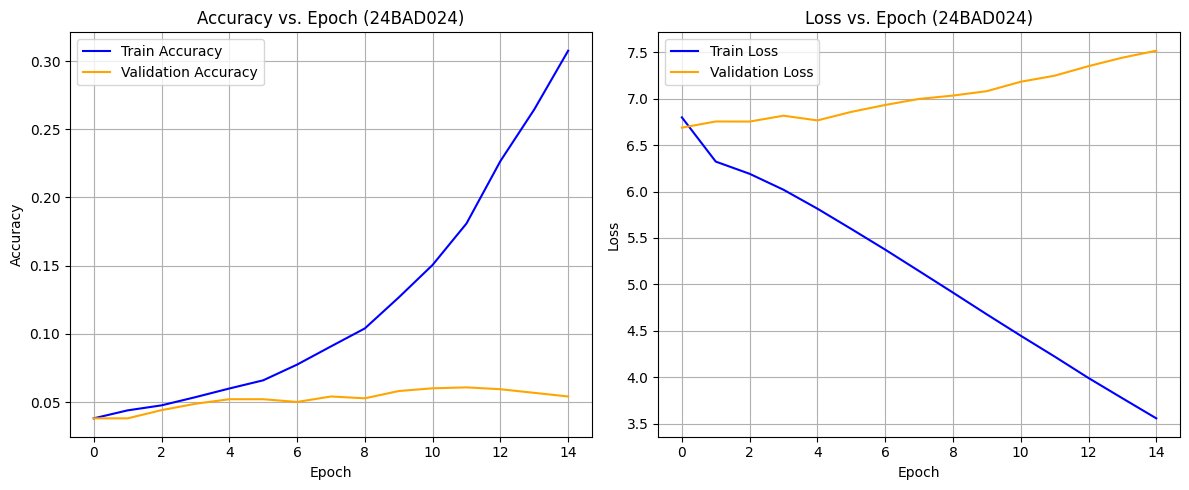

In [ ]:
# Task C: Model Training and Performance Evaluation
import matplotlib.pyplot as plt

STUDENT_ROLL_NO = "24BAD024"  # Replace with your Student Roll No
print(f"--- TASK C execution by Student Roll No: {STUDENT_ROLL_NO} ---")

epochs = 15
batch_size = 64

# 1 & 2. Train and Validate the model
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    verbose=1
)

# 3. Record metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\n--- Final Metrics Summary ---")
print(f"Training Accuracy:   {final_train_acc:.4f}")
print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Training Loss:       {final_train_loss:.4f}")
print(f"Validation Loss:     {final_val_loss:.4f}")

# 4. Visualize Accuracy and Loss curves
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title(f'Accuracy vs. Epoch ({STUDENT_ROLL_NO})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title(f'Loss vs. Epoch ({STUDENT_ROLL_NO})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Task D: Text Generation & Evaluation
STUDENT_ROLL_NO = "24BAD024"
print(f"--- TASK D execution by Student Roll No: {STUDENT_ROLL_NO} ---")

def generate_text(seed_text, next_words, model, tokenizer, max_sequence_len):
    """
    Generates text by repeatedly predicting the next word given a seed text.
    """
    output_text = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([output_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding='pre')

        predicted_probabilities = model.predict(token_list, verbose=0)
        predicted_word_index = np.argmax(predicted_probabilities, axis=-1)[0]

        # Find word corresponding to predicted index
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        if not output_word:
            break

        output_text += " " + output_word

    return output_text

# 1-3. Generate text samples using different seed inputs
seed_inputs = [
    "first citizen",
    "to be or not",
    "the king is",
    "good lord"
]

print("\n--- Text Generation Results ---")
for seed in seed_inputs:
    generated = generate_text(seed, next_words=10, model=model, tokenizer=tokenizer, max_sequence_len=max_sequence_len)
    print(f"\nSeed Input:     '{seed}'")
    print(f"Generated Text: '{generated}'")

# 4. Contextual & Coherence Observations
print("\n--- Observations ---")
print("1. Coherence: The generated words locally follow grammatically reasonable pairings due to N-gram structure.")
print("2. Limitations: Simple RNNs tend to suffer from vanishing gradients, leading to repeated words or drift in long sequences.")
print("3. Quality: Seeds present in Shakespearean style (e.g., 'first citizen') yield better contextual continuity than out-of-distribution prompts.")

--- TASK D execution by Student Roll No: 24BAD024 ---

--- Text Generation Results ---

Seed Input:     'first citizen'
Generated Text: 'first citizen the gods of the people o' the people and that'

Seed Input:     'to be or not'
Generated Text: 'to be or not and as as you are not and forenoon cushions vent'

Seed Input:     'the king is'
Generated Text: 'the king is the people i have not and to the people i'

Seed Input:     'good lord'
Generated Text: 'good lord to death and make that you chance to the morning'

--- Observations ---
1. Coherence: The generated words locally follow grammatically reasonable pairings due to N-gram structure.
2. Limitations: Simple RNNs tend to suffer from vanishing gradients, leading to repeated words or drift in long sequences.
3. Quality: Seeds present in Shakespearean style (e.g., 'first citizen') yield better contextual continuity than out-of-distribution prompts.
